### Load Dataset

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd


In [6]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

df = pd.DataFrame(x, columns = housing.feature_names)

df["Price"] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split ( X, y, test_size = 0.2, random_state = 42)

### Decision Tree

In [8]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor (random_state = 42)
tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Predictions

In [9]:
tree_pred = tree.predict(X_test)

### Evaluating

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    tree_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_pred
    )
)

r2 = r2_score(
    y_test,
    tree_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.45467918846899225
RMSE: 0.7037294974840077
R2: 0.622075845135081


### tree visualization

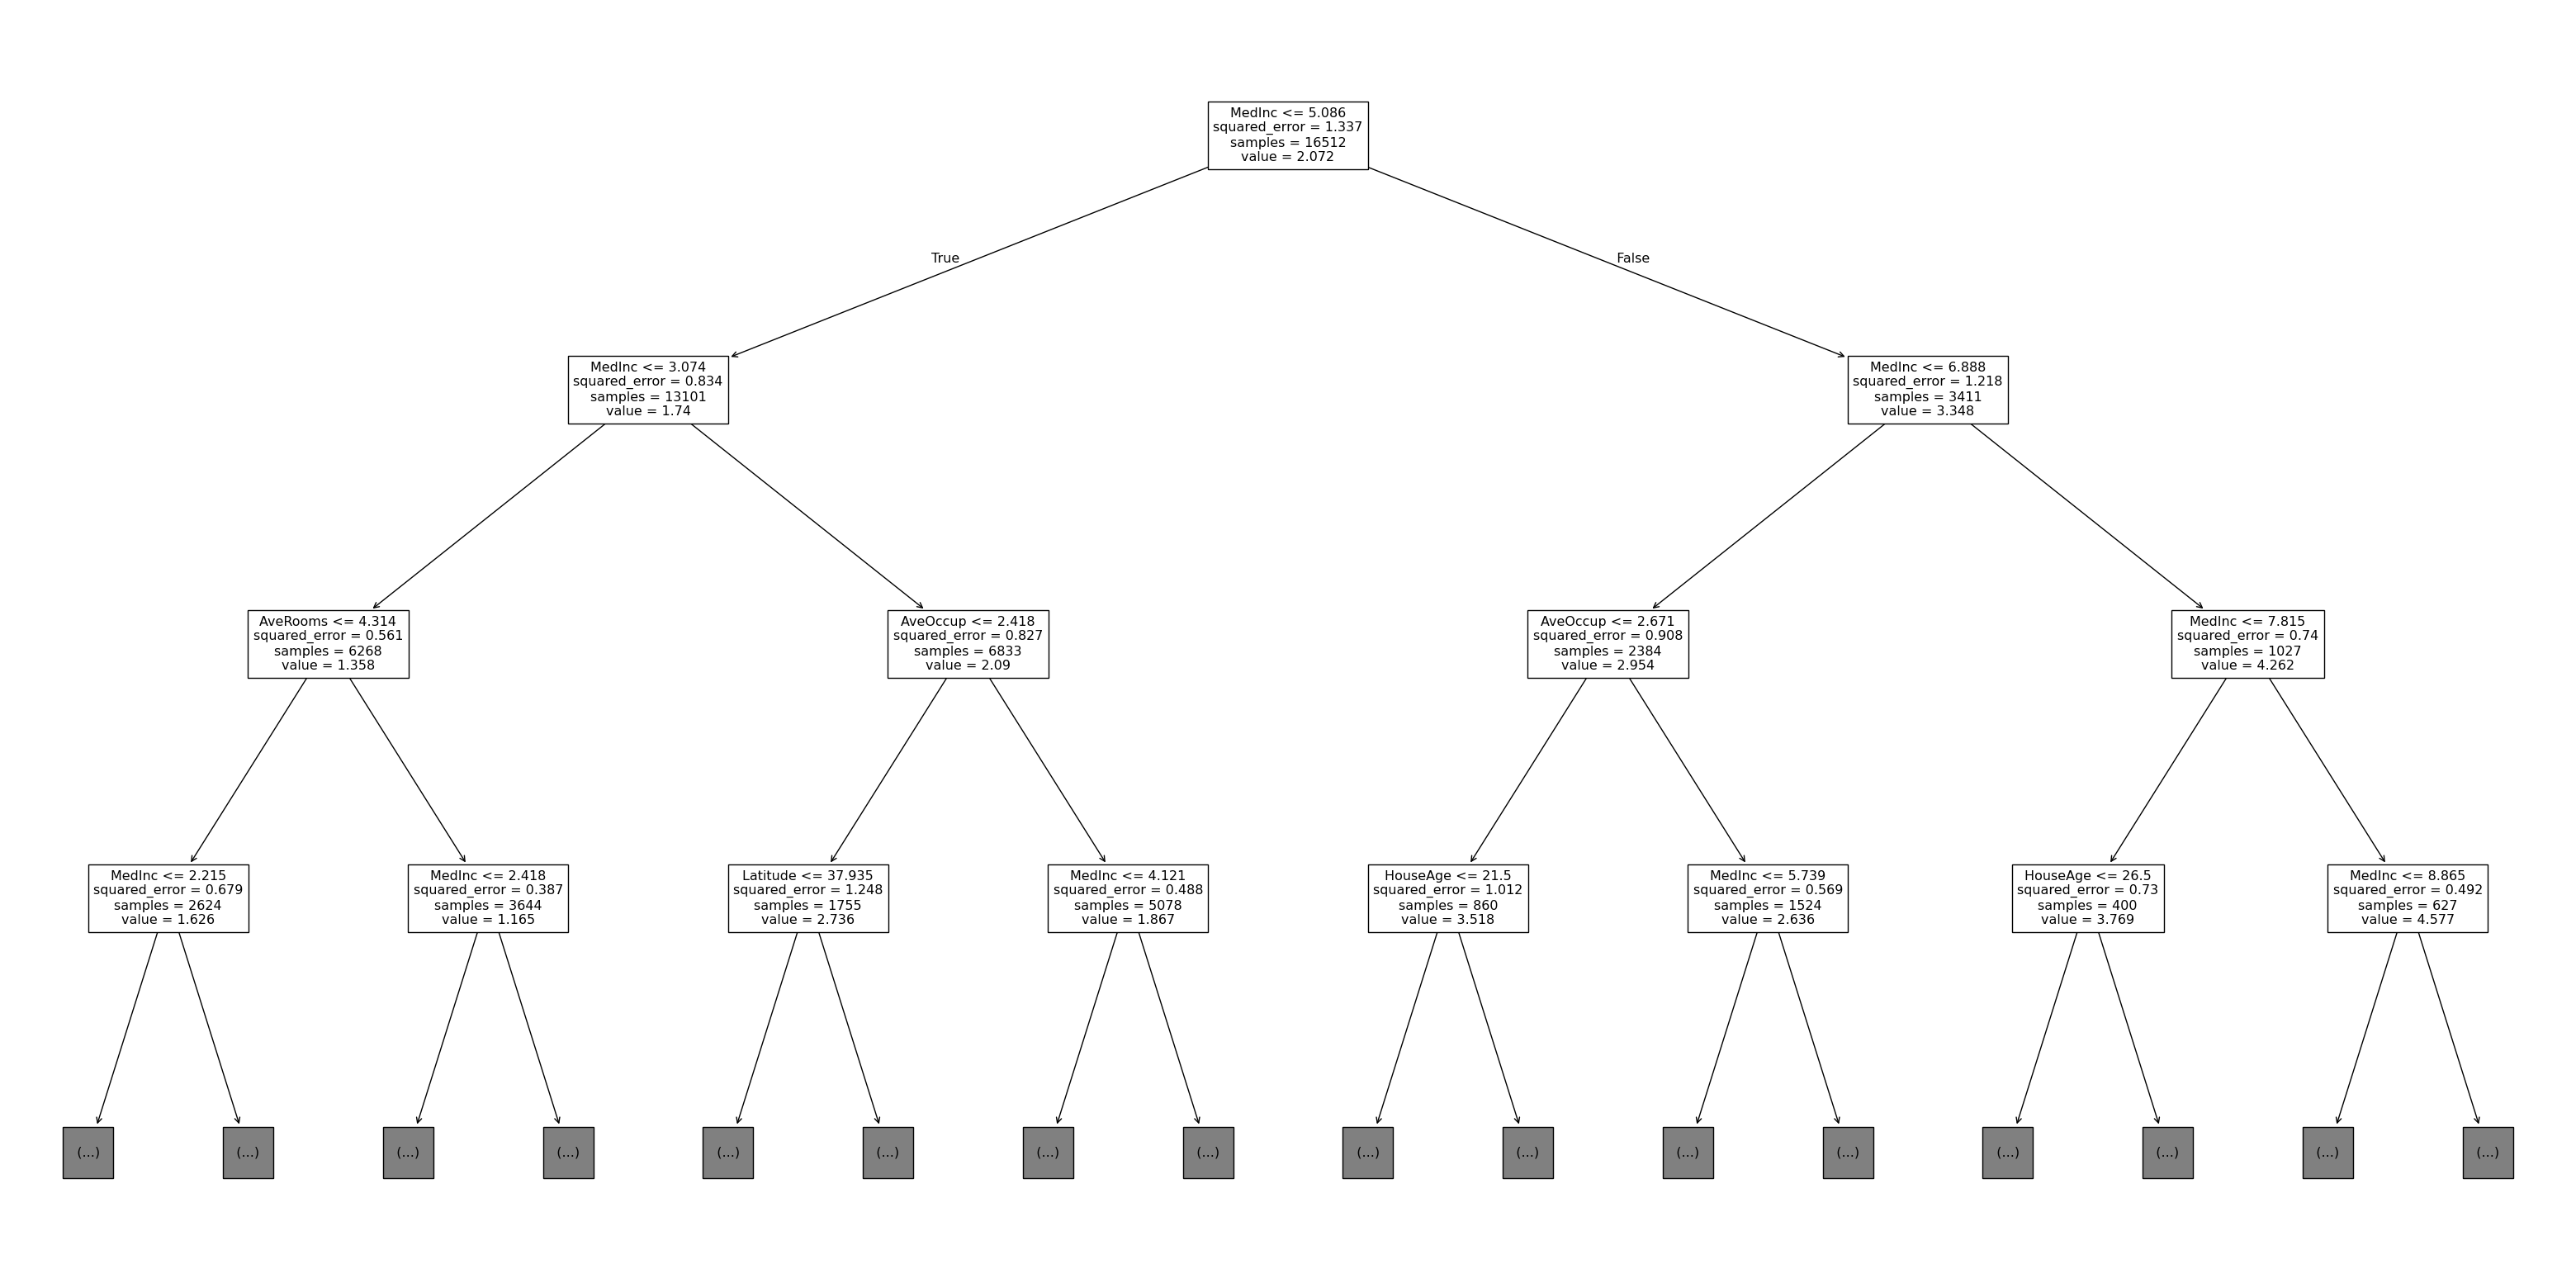

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize = (40,20))

plot_tree(tree, max_depth = 3, filled = False, feature_names = housing.feature_names)
plt.show()

### Random Forest

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
rf = RandomForestRegressor( n_estimators = 100, random_state = 42)

### Train

In [22]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
rf_pred = rf.predict(X_test)

### Evaluate Random Forest

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 0.32754256845930246
RMSE: 0.5053399773665033
R2: 0.8051230593157366


### Feature Importance

In [28]:
import pandas as pd

importance = pd.DataFrame ({"Feature": housing.feature_names, "Importance": rf.feature_importances_})

importance.sort_values("Importance", ascending = False)

,Feature,Importance
0,MedInc,0.524871
5,AveOccup,0.138443
6,Latitude,0.088936
7,Longitude,0.088629
1,HouseAge,0.054593
2,AveRooms,0.044272
4,Population,0.030650
3,AveBedrms,0.029606
